# Lunar Regional Data Struture Analysis
Default tile: WAC_GLOBAL_E0045S0450_100M with 212287 small craters (<10km)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from LRO_data_class import getRegionalLunarData

In [4]:
tiles = [
    ('WAC_GLOBAL_E300S0450_100M'),
    ('WAC_GLOBAL_E300N1350_100M'),
    ('WAC_GLOBAL_E300S1350_100M'),
    ('WAC_GLOBAL_E300N2250_100M'),
    ('WAC_GLOBAL_E300S2250_100M'),
    ('WAC_GLOBAL_E300S3150_100M'),
    ('WAC_GLOBAL_E300N0450_100M'),
    ('WAC_GLOBAL_E300N3150_100M'),
]

allDataTiles = []

for tile in tiles:
    data = getRegionalLunarData(tile)
    allDataTiles.append((tile, data))

    print(f'\n{tile}')
    print(data.shape, data.dtype)
    


WAC_GLOBAL_E300S0450_100M
(18194, 27291) float32

WAC_GLOBAL_E300N1350_100M
(18194, 27291) float32

WAC_GLOBAL_E300S1350_100M
(18194, 27291) float32

WAC_GLOBAL_E300N2250_100M
(18194, 27291) float32

WAC_GLOBAL_E300S2250_100M
(18194, 27291) float32

WAC_GLOBAL_E300S3150_100M
(18194, 27291) float32

WAC_GLOBAL_E300N0450_100M
(18194, 27291) float32

WAC_GLOBAL_E300N3150_100M
(18194, 27291) float32


In [5]:
summary = pd.DataFrame([{
    'tile': tile,
    'shape': dataTile.shape,
    'nulls': np.isnan(dataTile).sum(),
    'min': dataTile.min(),
    'max': dataTile.max(),
    'mean': dataTile.mean(),
    'std': dataTile.std()
} for tile, dataTile in allDataTiles])

display(summary)

,tile,shape,nulls,min,max,mean,std
0,WAC_GLOBAL_E300S0450_100M,"(18194, 27291)",0,-0.050797,0.470736,0.047326,0.018610
1,WAC_GLOBAL_E300N1350_100M,"(18194, 27291)",0,-0.002352,0.402926,0.056651,0.021023
2,WAC_GLOBAL_E300S1350_100M,"(18194, 27291)",0,-0.002678,0.562687,0.047924,0.018581
3,WAC_GLOBAL_E300N2250_100M,"(18194, 27291)",0,-0.036214,0.570455,0.054340,0.021250
4,WAC_GLOBAL_E300S2250_100M,"(18194, 27291)",0,-0.007670,0.398404,0.047253,0.019912
5,WAC_GLOBAL_E300S3150_100M,"(18194, 27291)",0,-0.018310,0.359843,0.044428,0.016791
6,WAC_GLOBAL_E300N0450_100M,"(18194, 27291)",0,-0.011826,0.395568,0.041002,0.017934
7,WAC_GLOBAL_E300N3150_100M,"(18194, 27291)",0,-0.002935,0.287448,0.033364,0.011798


## Image quality

In [6]:
allDataTilesScaled = []

for tile, dataTile in  allDataTiles:
    data = dataTile
    dataScaled = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data)) * 255
    dataScaled = np.nan_to_num(dataScaled).astype(np.uint8)

    allDataTilesScaled.append((tile, dataScaled))


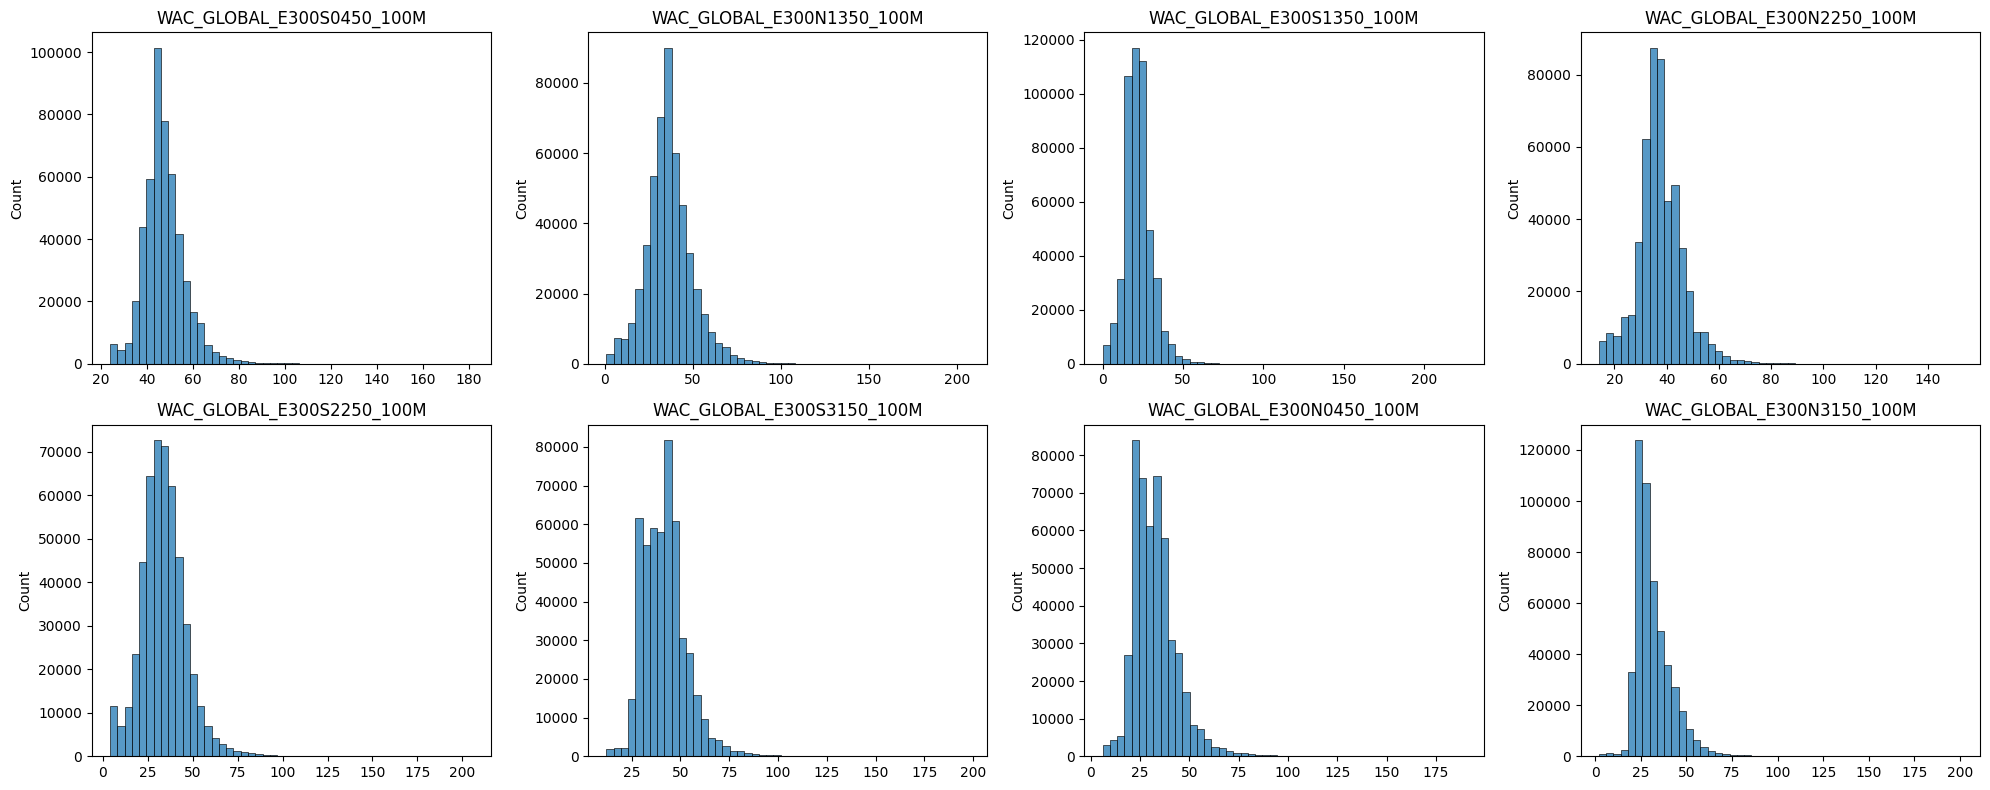

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (tile, data) in enumerate(allDataTilesScaled):
    row, col = divmod(idx, 4)
    sns.histplot(data.ravel()[::1000], bins=50, ax=axes[row][col])
    axes[row][col].set_title(tile)

plt.tight_layout()
plt.show()

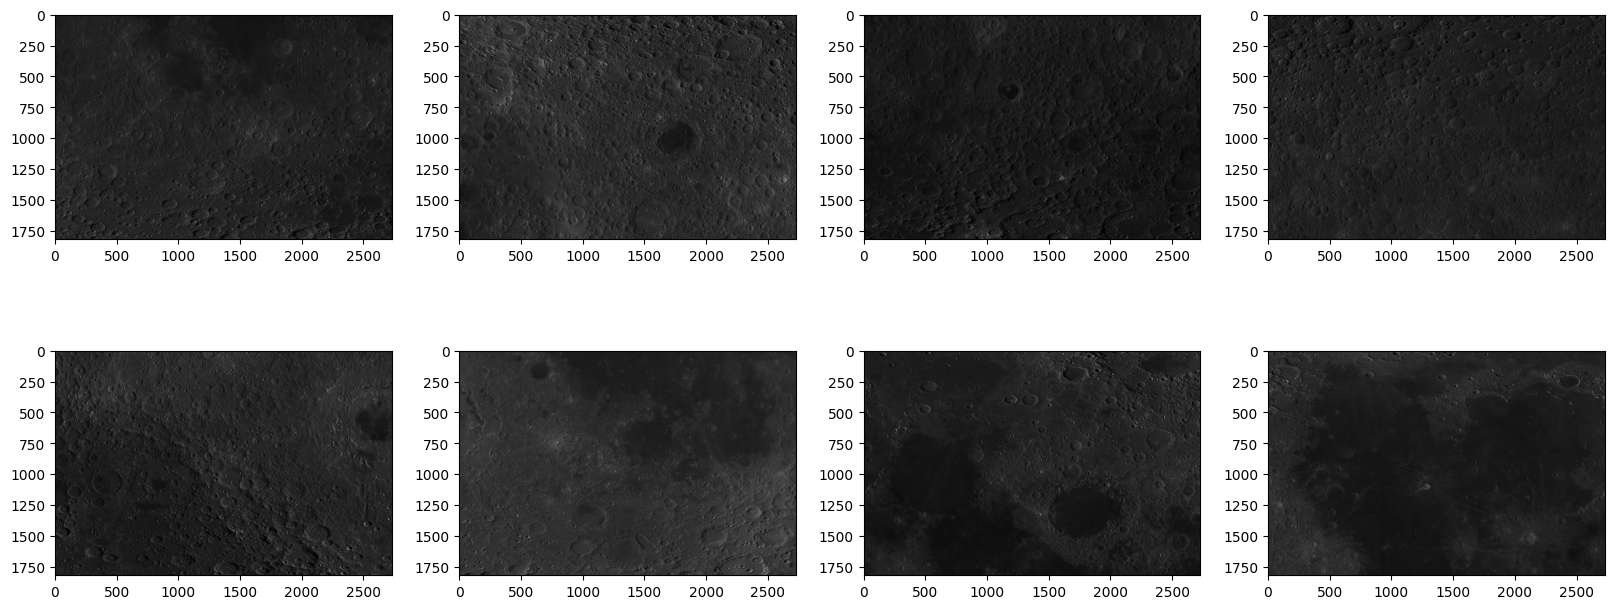

In [8]:
# two visible peaks: two distinct terrain types —> a mix of dark maria and brighter highlands.
# E300N1350, E300N2250, E300N3150

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (tile, data) in enumerate(allDataTilesScaled):
    row, col = divmod(idx, 4)
    axes[row][col].imshow(data[::10, ::10], cmap='gray')
